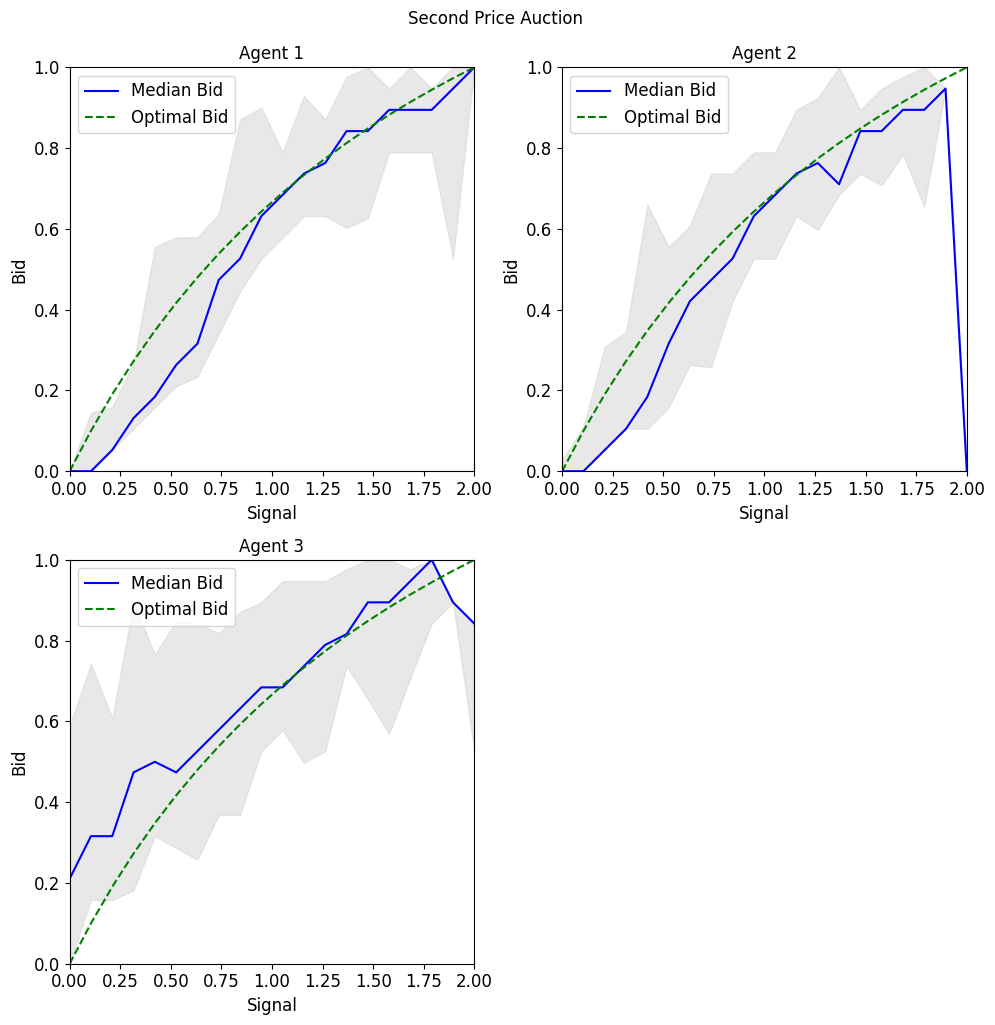

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class QLearningAgent:
    def __init__(self, action_min=0, action_max=1, granularity=20, epsilon=0.99, alpha=0.1, epsilon_decay=0.99995):
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_initial = epsilon
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.signal = None
        self.state = None

    def get_state(self, signal):
        bin_centers = np.linspace(0, 2, self.granularity)
        return np.argmin(np.abs(bin_centers - signal))
    
    def refresh_signal(self, true_valuation):
        self.signal = np.random.uniform(0, 2 * true_valuation)
        self.state = self.get_state(self.signal)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)
        self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

class SecondPriceAuction:
    def __init__(self, agents, payment_rule=None):
        self.agents = agents
        self.payment_rule = payment_rule

    def run_auction(self, true_valuation):
        for agent in self.agents:
            agent.refresh_signal(true_valuation)
        bids = [agent.choose_action() for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            reward = true_valuation - payment if idx == winner_index else 0
            agent.feedback(reward, bids[idx])
        return {"winner": winner_index, "payment": payment, "bids": bids}

def run_single_simulation(agents, auction, num_rounds=10000):
    for _ in range(num_rounds):
        true_valuation = np.random.uniform(0, 1)
        auction.run_auction(true_valuation)
    return [agent.q_values for agent in agents]

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_signals = [[] for _ in range(len(agents))]
    for _ in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_signals = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_signals[i].append(avg_bids_for_signals)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_signals[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, figsize=(10, 10), grid_dims=(2, 2), xlim=(0,2), ylim=(0,1), title=None, fontsize=12):
    fig, axes = plt.subplots(grid_dims[0], grid_dims[1], figsize=figsize)
    axes = axes.flatten()
    signals = np.linspace(0, 2, agents[0].granularity)
    
    for i, agent in enumerate(agents):
        ax = axes[i]
        ax.fill_between(signals, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
        ax.plot(signals, percentiles[i]["median"], label='Median Bid', color='blue')
        if optimal_bid_rule:
            optimal_bids = optimal_bid_rule(signals)
            ax.plot(signals, optimal_bids, label='Optimal Bid', color='green', linestyle='--')
        if xlim: ax.set_xlim(xlim)
        if ylim: ax.set_ylim(ylim)
        ax.set_xlabel('Signal', fontsize=fontsize)
        ax.set_ylabel('Bid', fontsize=fontsize)
        ax.set_title(f'Agent {i+1}', fontsize=fontsize)
        ax.legend(fontsize=fontsize)
        ax.tick_params(axis='both', which='major', labelsize=fontsize)

    # Remove extra subplots if fewer than 4
    for j in range(len(agents), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    if title: plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

def second_price_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    if len(winner_candidates) > 1:
        winner = np.random.choice(winner_candidates)
    else:
        winner = winner_candidates[0]
    
    second_highest_bid = np.partition(bids, -2)[-2]
    
    # Adding a tiny amount for tie-breaking to always give the highest bid
    second_highest_bid += 0.01
    return winner, second_highest_bid

def optimal_bid_spa(signals):
    return 2 * signals / (2 + signals)

agents = [QLearningAgent() for _ in range(3)]
spa_auction = SecondPriceAuction(agents, payment_rule=second_price_rule)
percentiles_spa = run_monte_carlo_simulation(agents, spa_auction, num_simulations=30, num_rounds=10000)
plot_monte_carlo_results(agents, percentiles_spa, optimal_bid_rule=optimal_bid_spa, title='Second Price Auction', grid_dims=(2, 2))



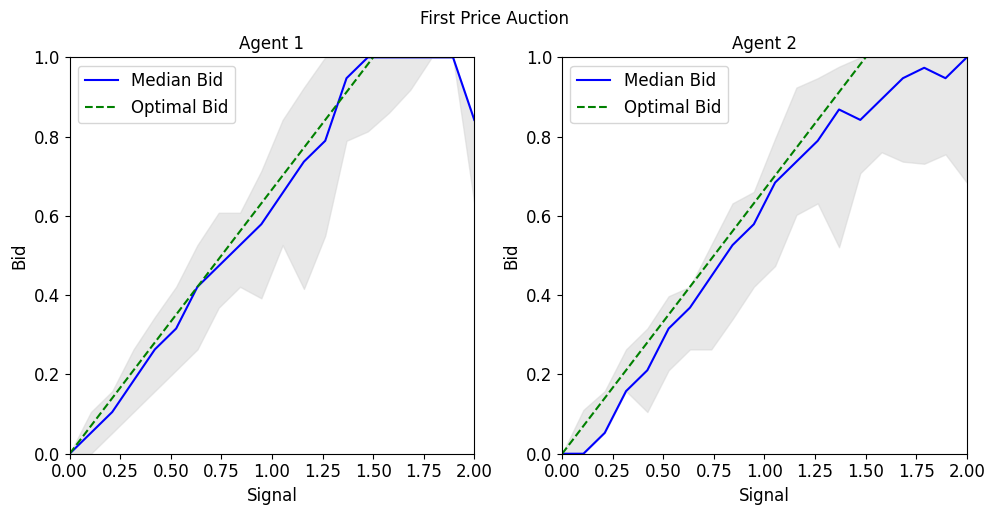

In [2]:
# First-Price Auction based on the example.

import numpy as np
import matplotlib.pyplot as plt

class QLearningAgent:
    def __init__(self, action_min=0, action_max=1, granularity=20, epsilon=0.99, alpha=0.1, epsilon_decay=0.99995):
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_initial = epsilon
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.signal = None
        self.state = None

    def get_state(self, signal):
        bin_centers = np.linspace(0, 2, self.granularity)
        return np.argmin(np.abs(bin_centers - signal))
    
    def refresh_signal(self, s_value, t_value):
        self.signal = s_value + t_value
        self.state = self.get_state(self.signal)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.reward_history.append(reward)
        self.update_q_values(action, reward)
        self.epsilon = max(0.05, self.epsilon * self.epsilon_decay)

class FirstPriceAuction:
    def __init__(self, agents):
        self.agents = agents

    def run_auction(self, s1, s2, t):
        # Refresh signals based on s1, s2, t
        self.agents[0].refresh_signal(s1, t)
        self.agents[1].refresh_signal(s2, t)
        
        bids = [agent.choose_action() for agent in self.agents]
        winning_bid = np.max(bids)
        winner_index = np.argmax(bids)
        
        # True valuation
        true_value = 0.5 * (self.agents[0].signal + self.agents[1].signal)
        
        # Reward is true valuation minus winning bid for the winner, and 0 for others
        for idx, agent in enumerate(self.agents):
            reward = true_value - winning_bid if idx == winner_index else 0
            agent.feedback(reward, bids[idx])
        return {"winner": winner_index, "winning_bid": winning_bid, "bids": bids}

def run_single_simulation(agents, auction, num_rounds=10000):
    for _ in range(num_rounds):
        s1, s2, t = np.random.uniform(0, 1), np.random.uniform(0, 1), np.random.uniform(0, 1)
        auction.run_auction(s1, s2, t)
    return [agent.q_values for agent in agents]

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_signals = [[] for _ in range(len(agents))]
    for _ in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_signals = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_signals[i].append(avg_bids_for_signals)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_signals[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, figsize=(10, 5), grid_dims=(1, 2), xlim=(0,2), ylim=(0,1), title=None, fontsize=12):
    fig, axes = plt.subplots(grid_dims[0], grid_dims[1], figsize=figsize)
    axes = axes.flatten()
    signals = np.linspace(0, 2, agents[0].granularity)
    
    for i, agent in enumerate(agents):
        ax = axes[i]
        ax.fill_between(signals, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
        ax.plot(signals, percentiles[i]["median"], label='Median Bid', color='blue')
        if optimal_bid_rule:
            optimal_bids = optimal_bid_rule(signals)
            ax.plot(signals, optimal_bids, label='Optimal Bid', color='green', linestyle='--')
        if xlim: ax.set_xlim(xlim)
        if ylim: ax.set_ylim(ylim)
        ax.set_xlabel('Signal', fontsize=fontsize)
        ax.set_ylabel('Bid', fontsize=fontsize)
        ax.set_title(f'Agent {i+1}', fontsize=fontsize)
        ax.legend(fontsize=fontsize)
        ax.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title: plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

def first_price_optimal_bid(signals):
    return (2/3) * signals

agents = [QLearningAgent() for _ in range(2)]
fp_auction = FirstPriceAuction(agents)
percentiles_fp = run_monte_carlo_simulation(agents, fp_auction, num_simulations=30, num_rounds=10000)
plot_monte_carlo_results(agents, percentiles_fp, optimal_bid_rule=first_price_optimal_bid, title='First Price Auction', grid_dims=(1, 2))

